# EXPERIMENT – 3
## 2D Transformations Using Homogeneous Coordinates

**Name:** Ojas B A  
**USN:** 1RVU23CSE321  
**Course:** Computer Graphics and Virtual Reality

### Aim
To implement 2D transformations using homogeneous coordinates and matrix representation.

In [1]:
%%writefile experiment3.cpp
#include <iostream>
#include <vector>
#include <cmath>
#include <iomanip>
using namespace std;

struct Point {
    double x, y;
};

using Matrix = vector<vector<double>>;

Point applyTransform(const Matrix& m, const Point& p) {
    double x = m[0][0] * p.x + m[0][1] * p.y + m[0][2] * 1.0;
    double y = m[1][0] * p.x + m[1][1] * p.y + m[1][2] * 1.0;
    return {x, y};
}

void printShape(const string& tag, const vector<Point>& shape) {
    for (const auto& p : shape) {
        cout << tag << " " << fixed << setprecision(2) << p.x << " " << p.y << "\n";
    }
}

vector<Point> transformShape(const vector<Point>& shape, const Matrix& m) {
    vector<Point> result;
    for (const auto& p : shape) {
        result.push_back(applyTransform(m, p));
    }
    return result;
}

int main() {
    vector<Point> original = {
        {-50, -40},
        {50, -40},
        {0, 60}
    };

    Matrix translation = {
        {1, 0, 40},
        {0, 1, 30},
        {0, 0, 1}
    };

    double angle = 45.0 * M_PI / 180.0;
    Matrix rotation = {
        {cos(angle), -sin(angle), 0},
        {sin(angle),  cos(angle), 0},
        {0, 0, 1}
    };

    Matrix scaling = {
        {1.5, 0, 0},
        {0, 1.5, 0},
        {0, 0, 1}
    };

    Matrix reflection = {
        {1, 0, 0},
        {0, -1, 0},
        {0, 0, 1}
    };

    Matrix shearing = {
        {1, 0.8, 0},
        {0, 1, 0},
        {0, 0, 1}
    };

    printShape("ORIGINAL", original);
    printShape("TRANSLATION", transformShape(original, translation));
    printShape("ROTATION", transformShape(original, rotation));
    printShape("SCALING", transformShape(original, scaling));
    printShape("REFLECTION", transformShape(original, reflection));
    printShape("SHEARING", transformShape(original, shearing));

    return 0;
}


Writing experiment3.cpp


In [2]:
!g++ experiment3.cpp -o experiment3
output = !./experiment3

shapes = {
    "ORIGINAL": [],
    "TRANSLATION": [],
    "ROTATION": [],
    "SCALING": [],
    "REFLECTION": [],
    "SHEARING": []
}

for line in output:
    tag, x, y = line.split()
    shapes[tag].append((float(x), float(y)))

for key in shapes:
    print(key, ":", shapes[key])


ORIGINAL : [(-50.0, -40.0), (50.0, -40.0), (0.0, 60.0)]
TRANSLATION : [(-10.0, -10.0), (90.0, -10.0), (40.0, 90.0)]
ROTATION : [(-7.07, -63.64), (63.64, 7.07), (-42.43, 42.43)]
SCALING : [(-75.0, -60.0), (75.0, -60.0), (0.0, 90.0)]
REFLECTION : [(-50.0, 40.0), (50.0, 40.0), (0.0, -60.0)]
SHEARING : [(-82.0, -40.0), (18.0, -40.0), (48.0, 60.0)]


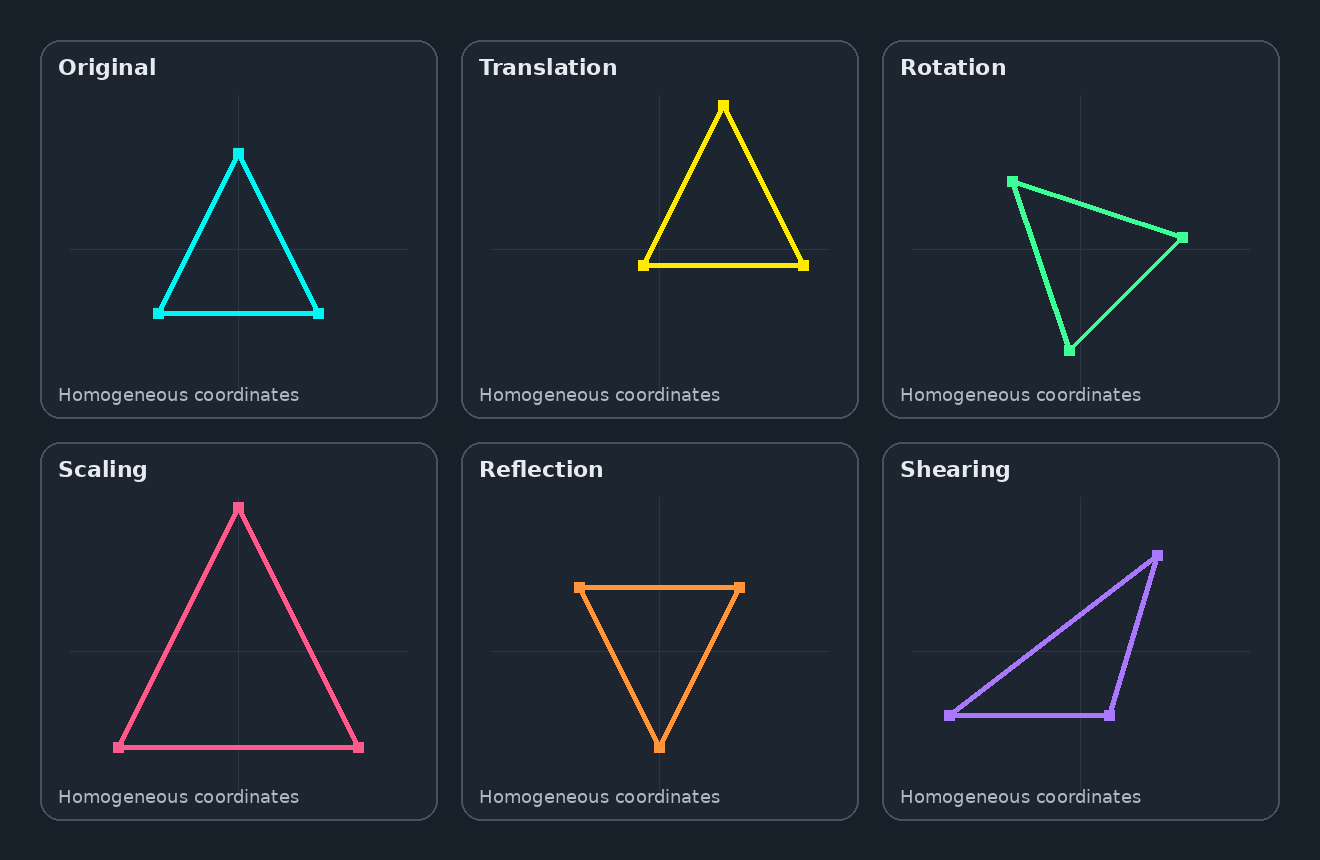

Saved as experiment3_2d_transformations.png


In [3]:
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

W, H = 1320, 860
bg = (23, 31, 40)
panel_fill = (28, 37, 48)
panel_border = (70, 82, 96)
text_color = (230, 235, 240)

img = Image.new("RGB", (W, H), bg)
draw = ImageDraw.Draw(img)

margin = 40
gap = 24
cols, rows = 3, 2
panel_w = (W - 2 * margin - (cols - 1) * gap) // cols
panel_h = (H - 2 * margin - (rows - 1) * gap) // rows

layout = [
    ("ORIGINAL", "Original", (0, 245, 245)),
    ("TRANSLATION", "Translation", (255, 235, 0)),
    ("ROTATION", "Rotation", (60, 255, 150)),
    ("SCALING", "Scaling", (255, 90, 140)),
    ("REFLECTION", "Reflection", (255, 150, 60)),
    ("SHEARING", "Shearing", (170, 120, 255)),
]

try:
    font_title = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22)
    font_sub = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18)
except:
    font_title = None
    font_sub = None

def map_point(p, cx, cy, scale=1.6):
    x, y = p
    return (cx + x * scale, cy - y * scale)

for idx, (key, label, color) in enumerate(layout):
    r = idx // cols
    c = idx % cols
    x0 = margin + c * (panel_w + gap)
    y0 = margin + r * (panel_h + gap)
    x1 = x0 + panel_w
    y1 = y0 + panel_h

    draw.rounded_rectangle((x0, y0, x1, y1), radius=20, fill=panel_fill, outline=panel_border, width=2)
    draw.text((x0 + 18, y0 + 14), label, fill=text_color, font=font_title)

    cx = (x0 + x1) / 2
    cy = (y0 + y1) / 2 + 20
    draw.line((x0 + 30, cy, x1 - 30, cy), fill=(45, 55, 68), width=1)
    draw.line((cx, y0 + 55, cx, y1 - 30), fill=(45, 55, 68), width=1)

    pts = [map_point(p, cx, cy) for p in shapes[key]]
    draw.line(pts + [pts[0]], fill=color, width=5)

    for px, py in pts:
        draw.rectangle((px - 5, py - 5, px + 5, py + 5), fill=color)

    draw.text((x0 + 18, y1 - 34), "Homogeneous coordinates", fill=(175, 185, 195), font=font_sub)

img.save("experiment3_2d_transformations.png")
display(img)
print("Saved as experiment3_2d_transformations.png")


### Result
Translation, rotation, scaling, reflection, and shearing were implemented successfully using homogeneous coordinates and matrix representation.